In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [24]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [25]:
print("Fund Master:", fund.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [26]:
print("AUM")
print(aum.columns.tolist())

print("\nSIP")
print(sip.columns.tolist())

print("\nCategory")
print(category.columns.tolist())

print("\nFolio")
print(folio.columns.tolist())

print("\nHoldings")
print(holdings.columns.tolist())

print("\nBenchmark")
print(benchmark.columns.tolist())

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Holdings
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Benchmark
['date', 'index_name', 'close_value']


In [27]:
datasets = {
    "Fund Master": fund,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV,46000,3
2,AUM,90,5
3,SIP,48,6
4,Category,144,3
5,Folio,21,6
6,Performance,40,19
7,Transactions,32778,13
8,Holdings,322,8
9,Benchmark,8050,3


In [28]:
nav["date"] = pd.to_datetime(nav["date"])

nav_plot = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

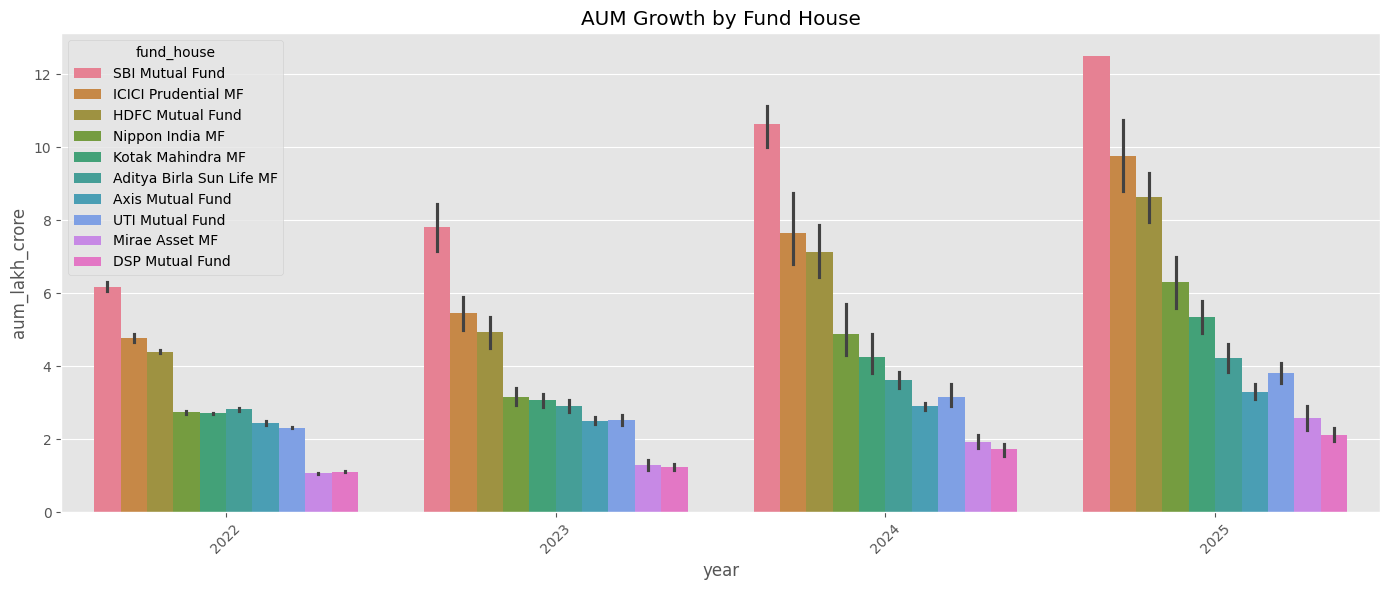

In [29]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/charts/aum_growth.png")
plt.show()

In [30]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow"
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(), "month"],
    y=sip["sip_inflow_crore"].max(),
    text="₹31,002 Cr Peak",
    showarrow=True
)

fig.show()

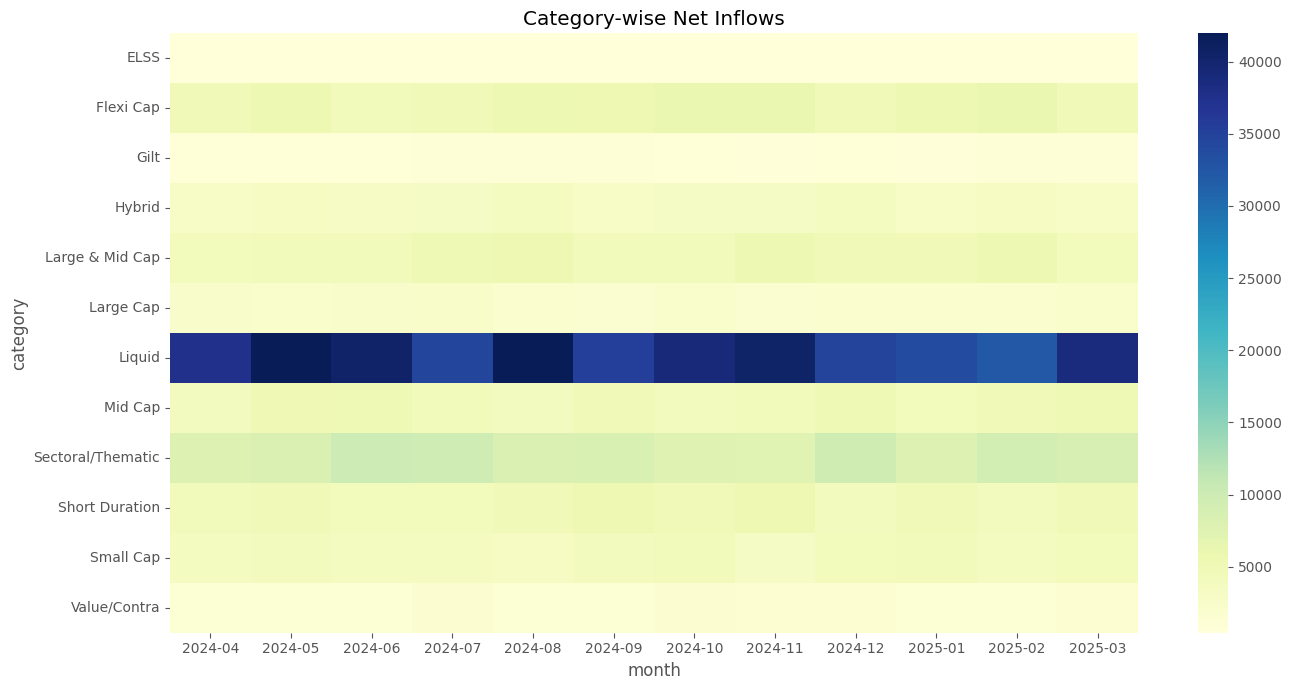

In [31]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")
plt.tight_layout()
plt.savefig("../reports/charts/category_heatmap.png")
plt.show()

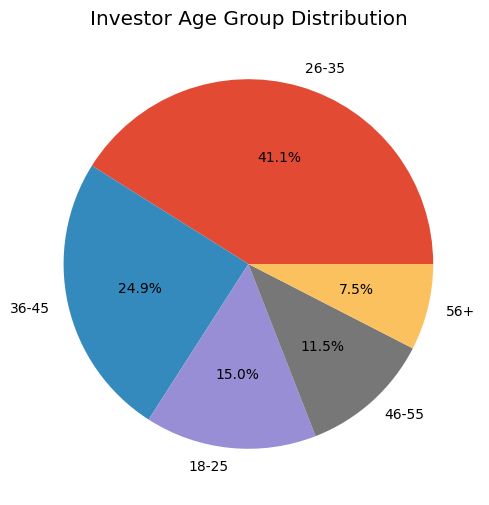

In [32]:
plt.figure(figsize=(8,6))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")
plt.savefig("../reports/charts/age_group_distribution.png")
plt.show()

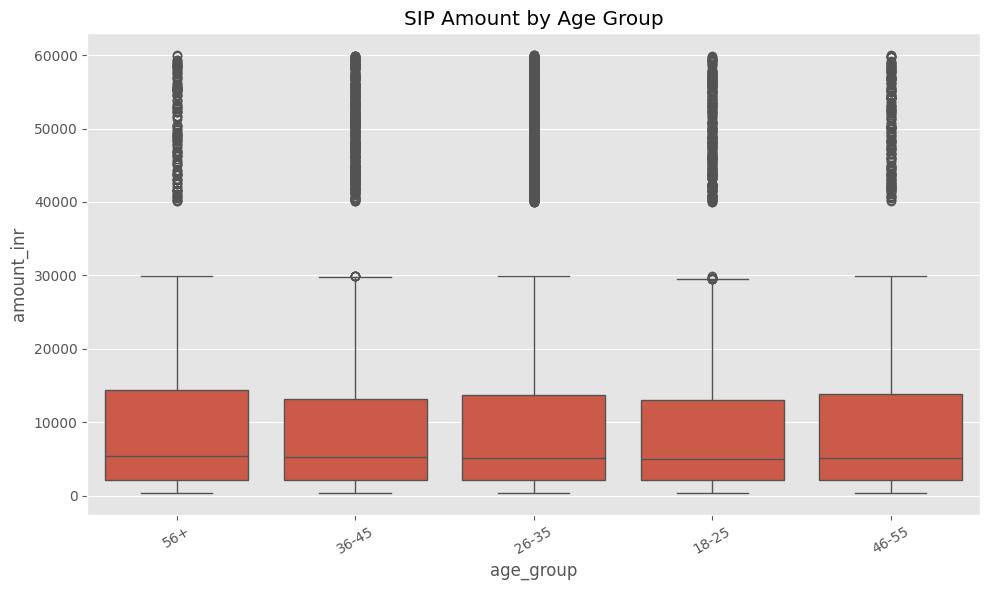

In [33]:
sip_df = transactions[
    transactions["transaction_type"]=="SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../reports/charts/sip_boxplot.png")
plt.show()

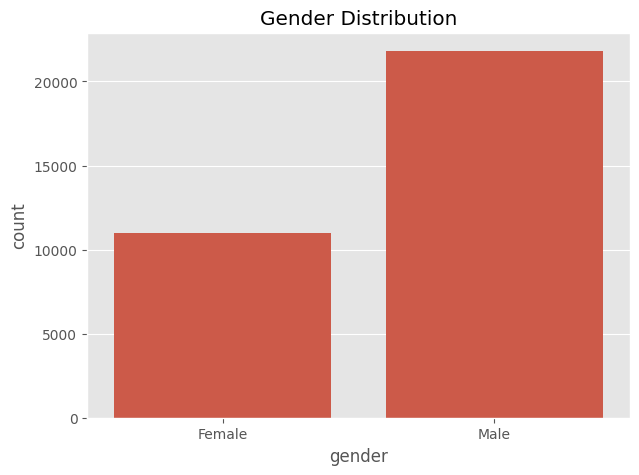

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")
plt.savefig("../reports/charts/gender_distribution.png")
plt.show()

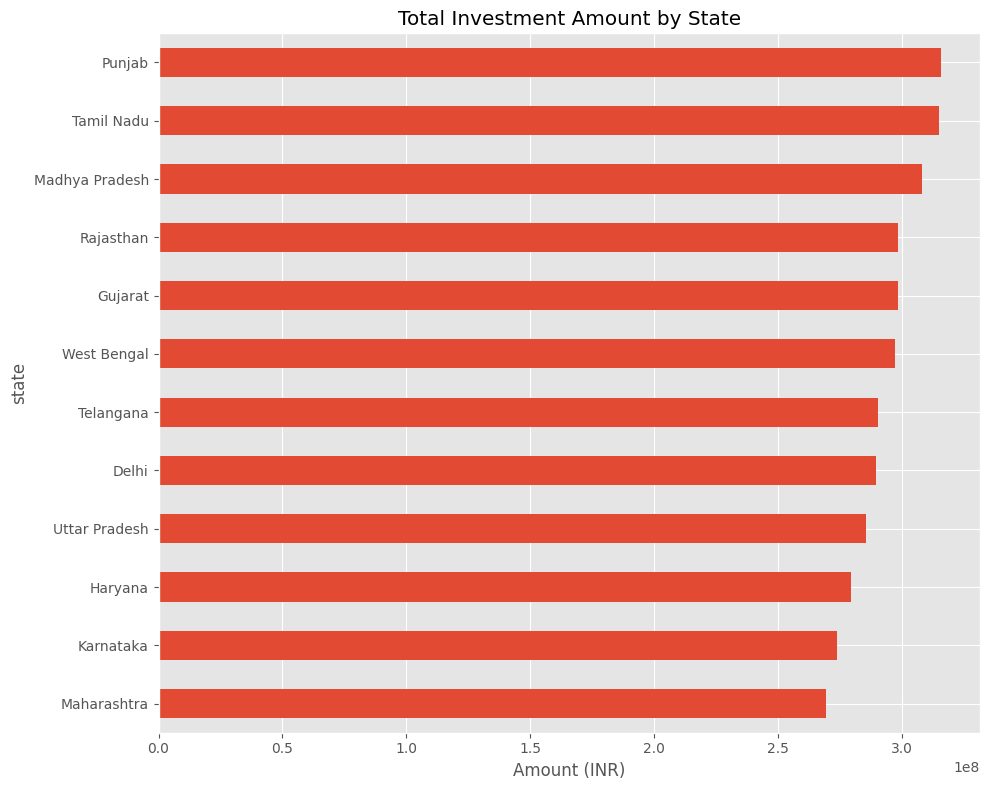

In [35]:
state_df = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_df.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (INR)")

plt.tight_layout()
plt.savefig("../reports/charts/state_distribution.png")
plt.show()

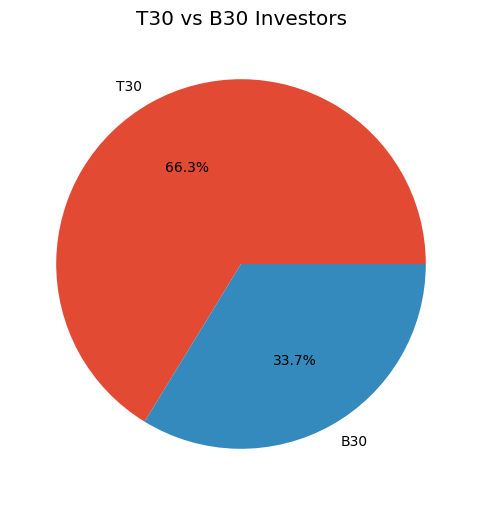

In [36]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.savefig("../reports/charts/city_tier.png")
plt.show()

In [37]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth"
)

fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.show()

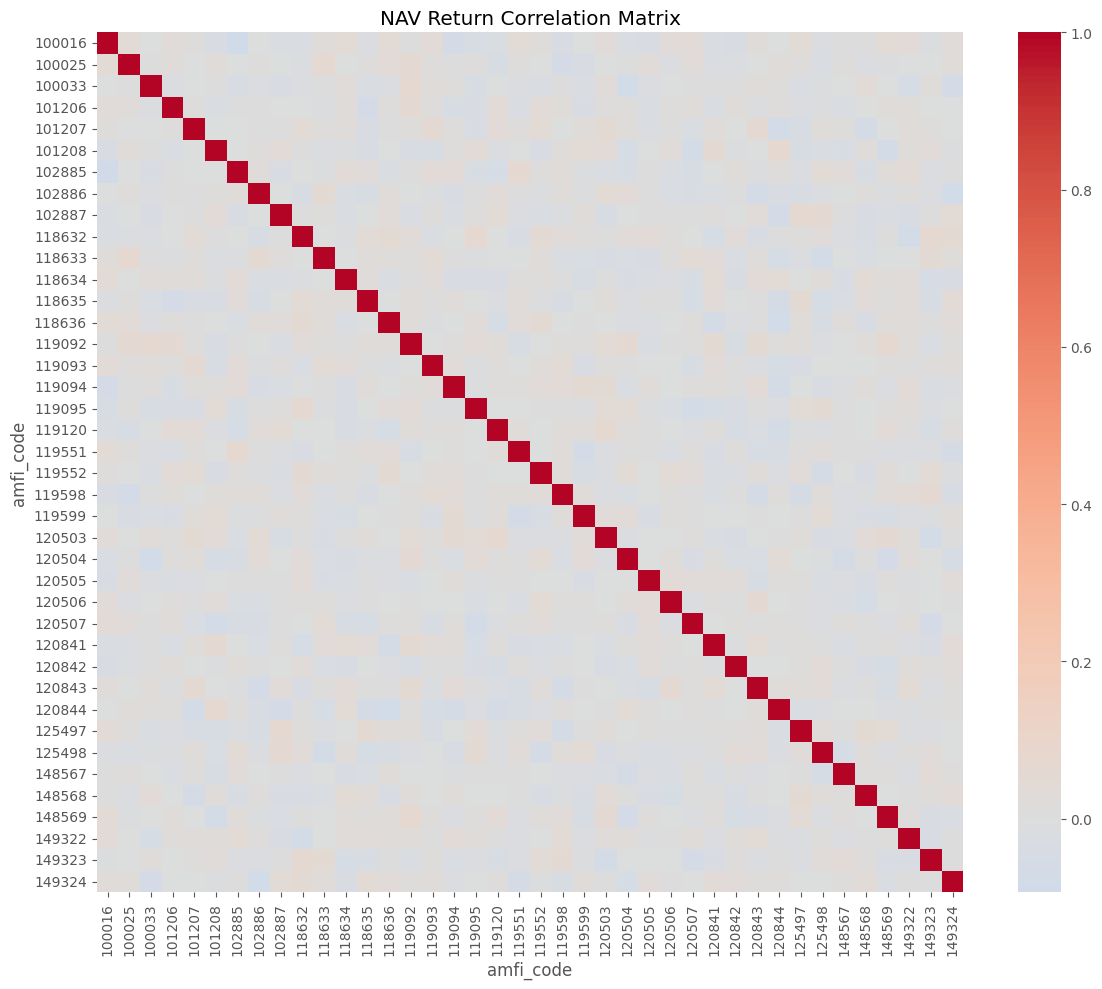

In [38]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()
plt.savefig("../reports/charts/correlation_matrix.png")
plt.show()

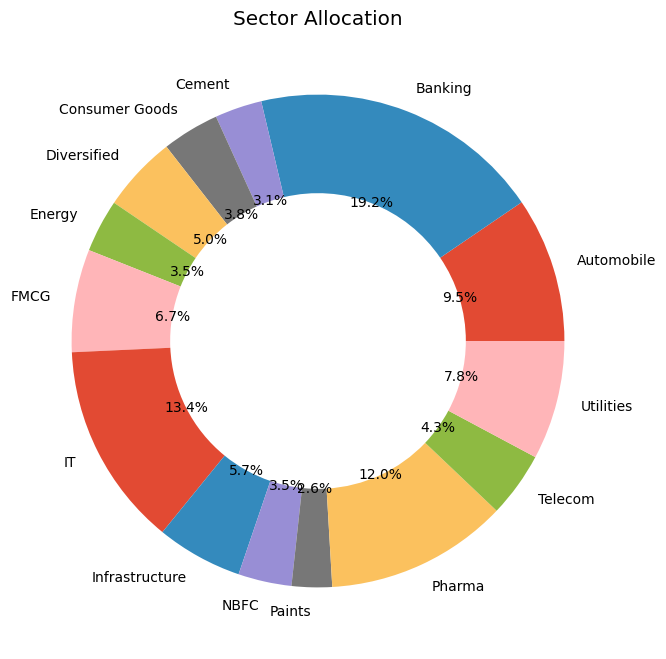

In [39]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig("../reports/charts/sector_donut.png")
plt.show()

In [40]:
summary = pd.DataFrame({

    "Dataset":[
        "Fund Master",
        "NAV",
        "AUM",
        "SIP",
        "Category",
        "Folio",
        "Performance",
        "Transactions",
        "Holdings",
        "Benchmark"
    ],

    "Rows":[
        len(fund),
        len(nav),
        len(aum),
        len(sip),
        len(category),
        len(folio),
        len(performance),
        len(transactions),
        len(holdings),
        len(benchmark)
    ]

})

summary

,Dataset,Rows
0,Fund Master,40
1,NAV,46000
2,AUM,90
3,SIP,48
4,Category,144
5,Folio,21
6,Performance,40
7,Transactions,32778
8,Holdings,322
9,Benchmark,8050


# Key EDA Findings

1. Daily NAV values generally show an upward trend from 2022 to 2026.
2. SBI Mutual Fund maintains one of the highest AUM values among the selected fund houses.
3. Monthly SIP inflows increase steadily and peak in December 2025.
4. Category-wise inflows vary significantly across months.
5. Most investors belong to a few dominant age groups.
6. SIP investment amounts differ across age groups.
7. Investment activity is concentrated in a handful of states.
8. Folio counts show consistent industry growth over the analysis period.
9. Most selected funds exhibit positive correlations in daily returns.
10. Portfolio allocations are concentrated in a few major sectors.